In [1]:
import numpy as np

A = np.array([[1, 2],
              [3, 4]])

B = np.array([[5],
              [6]])

C = np.matmul(A, B)

In [2]:
C

array([[17],
       [39]])

In [3]:
import numpy as np

x1_vals = np.linspace(-5, 5, 5)
x2_vals = np.linspace(-5, 5, 5)

In [4]:
X1, X2 = np.meshgrid(x1_vals, x2_vals)

In [5]:
import torch

# Scalar: 0D tensor
scalar = torch.tensor(5)
print("Scalar:", scalar)
print("Shape:", scalar.shape)

# Vector: 1D tensor
vector = torch.tensor([1, 2, 3])
print("\nVector:", vector)
print("Shape:", vector.shape)

# Matrix: 2D tensor
matrix = torch.tensor([[1, 2], [3, 4]])
print("\nMatrix:", matrix)
print("Shape:", matrix.shape)

# 3D Tensor
tensor_3d = torch.randn(2, 3, 4)  # random numbers
print("\n3D Tensor:", tensor_3d)
print("Shape:", tensor_3d.shape)


Scalar: tensor(5)
Shape: torch.Size([])

Vector: tensor([1, 2, 3])
Shape: torch.Size([3])

Matrix: tensor([[1, 2],
        [3, 4]])
Shape: torch.Size([2, 2])

3D Tensor: tensor([[[-0.2396,  1.3225, -1.0357,  0.6270],
         [-1.8865, -0.2409, -0.3611,  0.3724],
         [ 1.5101,  2.1311,  0.9165,  0.3593]],

        [[ 1.5757, -1.1284, -1.7683,  0.2008],
         [ 0.8503,  1.0938, -2.0725, -2.3518],
         [ 1.5996,  0.3397, -0.1122,  1.9273]]])
Shape: torch.Size([2, 3, 4])


In [ ]:
# Text data: (batch_size, sequence_length, embedding_dim)

# (32, 100, 768) → 32 sentences, each with 100 tokens, each token represented by a 768-dimensional embedding.

In [1]:
import torch

# Step 1: Tiny toy dataset
X = torch.tensor([[1.0], [2.0], [3.0], [4.0]])  # Inputs
Y = torch.tensor([[2.0], [4.0], [6.0], [8.0]])  # Ground truth

# Step 2: Manually initialized weight and bias
W = torch.tensor([[0.5]], requires_grad=True)
b = torch.tensor([0.0], requires_grad=True)

# Step 3: Define predict function (ŷ = XW + b)
def predict(X):
    return torch.matmul(X, W) + b

# Step 4: Make predictions
y_pred = predict(X)

# Step 5: Show results
print("Predictions:")
print(y_pred)


Predictions:
tensor([[0.5000],
        [1.0000],
        [1.5000],
        [2.0000]], grad_fn=<AddBackward0>)


In [ ]:
inputs = data.iloc[:, :-1].values       # First 8 columns = features
targets = data.iloc[:, -1].values.reshape(-1, 1)

In [ ]:
# Define MSE loss function
def mse_loss(preds, targets):
    return ((preds - targets)**2).mean()

In [ ]:
import torch
import pandas as pd
from sklearn.preprocessing import StandardScaler

# 1. Load dataset
data = pd.read_csv("Concrete_Data.csv")  # Adjust path as needed

# 2. Separate features and target
inputs = data.iloc[:, :-1].values       # First 8 columns = features
targets = data.iloc[:, -1].values.reshape(-1, 1)    #reshape -1 means figure rows, but 1 column  # Last column = target

# 3. Normalize input features
scaler = StandardScaler()
inputs_scaled = scaler.fit_transform(inputs)

# 4. Convert to PyTorch tensors
inputs_tensor = torch.tensor(inputs_scaled, dtype=torch.float32)
targets_tensor = torch.tensor(targets, dtype=torch.float32)

# 5. Shuffle and split into training (80%) and test (20%) sets
torch.manual_seed(42)
n_samples = inputs_tensor.shape[0]
indices = torch.randperm(n_samples)
split_idx = int(n_samples * 0.8)

train_indices = indices[:split_idx]
test_indices = indices[split_idx:]

X_train = inputs_tensor[train_indices]
y_train = targets_tensor[train_indices]
X_test = inputs_tensor[test_indices]
y_test = targets_tensor[test_indices]

# 6. Initialize model parameters
num_features = X_train.shape[1]  # Should be 8
W = torch.randn((num_features, 1), requires_grad=True)
W.data *= 0.01  # Scale down initial values
b = torch.zeros((1,), requires_grad=True)

# 7. Confirm everything is set up
print("Training set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])
print("Weight shape:", W.shape)
print("Bias shape:", b.shape)

FileNotFoundError: [Errno 2] No such file or directory: 'Concrete_Data.csv'

In [3]:
# Set learning rate and number of training epochs
learning_rate = 0.001
epochs = 100

# Training loop
for epoch in range(epochs):
    # 1. Forward pass: compute predictions
    y_pred = predict(X_train)
    
    # 2. Compute loss
    loss = mse_loss(y_pred, y_train)
    
    # 3. Backward pass: compute gradients
    loss.backward()

    # 4. Update parameters
    with torch.no_grad():
        W -= learning_rate * W.grad
        b -= learning_rate * b.grad

    # 5. Zero gradients
    W.grad.zero_()
    b.grad.zero_()

    # Print loss every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}: Loss = {loss.item():.4f}")


NameError: name 'X_train' is not defined

In [4]:


import torch

# Define ReLU manually
def my_relu(x):
    return torch.clamp(x, min=0)

# Test on a sample tensor
test_x = torch.tensor([-2.0, -1.0, 0.0, 1.0, 2.0])
print("Input:", test_x)
print("ReLU Output:", my_relu(test_x))


Input: tensor([-2., -1.,  0.,  1.,  2.])
ReLU Output: tensor([0., 0., 0., 1., 2.])


In [5]:
# Reuse dimensions
input_dim_t = 1
hidden_dim_t = 4
output_dim_t = 1

# Sample input
x_t = torch.tensor([[1.0], [2.0], [3.0], [4.0]])

# Set seed for reproducibility
torch.manual_seed(42)

# Initialize parameters with requires_grad=True
W1t_relu = torch.randn(input_dim_t, hidden_dim_t, requires_grad = True)
b1t_relu = torch.randn(hidden_dim_t, requires_grad = True)
W2t_relu = torch.randn(hidden_dim_t, output_dim_t ,requires_grad = True)
b2t_relu = torch.randn(output_dim_t, requires_grad = True)

# Define ReLU activation
def my_relu_t(x):
    return torch.clamp(x, min=0)

# Define prediction function with ReLU
def predict_relu_t(X):
    hidden = my_relu_t(X @ W1t_relu + b1t_relu)
    output = hidden @ W2t_relu + b2t_relu
    return output

# Compute predictions
y_pred_relu_t = predict_relu_t(x_t)

# Print output
print("y_pred_relu_t:", y_pred_relu_t)

y_pred_relu_t: tensor([[2.4169],
        [2.5614],
        [2.7641],
        [3.2137]], grad_fn=<AddBackward0>)


## 4. Building a Custom MLP using `nn.Module`

### Why Use a Custom Class for an MLP?

While `nn.Sequential` is a great shortcut for prototyping models, in most real-world scenarios we define our models using **custom classes**. This provides:

- Greater flexibility and control over architecture  
- Easier debugging and extension  
- More expressive forward passes

### 🔍 What's the Structure of a Custom Neural Network?

In PyTorch, we define a model by creating a class that:

- Inherits from `nn.Module`  
- Defines the layers in the `__init__()` method  
- Describes the forward pass in a `forward()` method

Basic structure:

```python
class MyModel(nn.Module):
    def __init__(self):
        super().__init__()
        # define layers

    def forward(self, x):
        # apply layers to input x
        return output
```

Let’s see how this works using a concrete example.


### Basic MLP Using Custom Class (1 Hidden Layer)

We’ll define a model with:

- 8 input features (Concrete dataset)  
- 1 hidden layer with **16 neurons** and **ReLU activation**  
- 1 output neuron for **regression**

🖥️ **Code Cell:** Simple MLP with One Hidden Layer


Making a classifier NN

In [12]:
import torch
import torch.nn as nn

# Custom MLP class for regression
class ConcreteMLP(nn.Module):
    def __init__(self, input_size=8, hidden_size=16, output_size=1):
        super(ConcreteMLP, self).__init__()
        
        self.fc1 = nn.Linear(input_size, hidden_size)  # First hidden layer
        self.relu = nn.ReLU()                          # Activation
        self.fc2 = nn.Linear(hidden_size, output_size) # Output layer
    
    def forward(self, x):
        x = self.fc1(x)   # Apply first linear layer
        x = self.relu(x)  # Apply ReLU activation
        x = self.fc2(x)   # Apply output layer
        return x

# Create model instance
model = ConcreteMLP()
print(model)


ConcreteMLP(
  (fc1): Linear(in_features=8, out_features=16, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=16, out_features=1, bias=True)
)


In [13]:
# Step 1: Define the model class
class CustomMLPModel(nn.Module):
    def __init__(self):
        super(CustomMLPModel, self).__init__()
        
        # Define the layers
        self.fc1 = nn.Linear(6,24)   # Input layer → 24 hidden units
        self.relu1 = nn.ReLU()       # First activation
        self.fc2 = nn.Linear(24,12) # Second hidden layer
        self.relu2 = nn.ReLU()       # Second activation
        self.fc3 = nn.Linear(12,1)   # Output layer → 1 unit

    # Step 2: Define the forward pass
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        return x

# Step 3: Instantiate and print the model
custom_model = CustomMLPModel()
print(custom_model)

CustomMLPModel(
  (fc1): Linear(in_features=6, out_features=24, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=24, out_features=12, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=12, out_features=1, bias=True)
)


In [ ]:
import pandas as pd
import torch
from sklearn.preprocessing import StandardScaler

# Load the Concrete dataset
data = pd.read_csv("Concrete_Data.csv")

# Separate features and target
X = data.iloc[:, :-1].values  # First 8 columns
y = data.iloc[:, -1].values.reshape(-1, 1)  # Last column (strength)

# Standardize inputs
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert to PyTorch tensors
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)

# Set seed and shuffle
torch.manual_seed(42)
num_samples = X_tensor.shape[0]
indices = torch.randperm(num_samples)

# 80/20 split
split_idx = int(0.8 * num_samples)
train_idx = indices[:split_idx]
test_idx = indices[split_idx:]

# Create splits
X_train = X_tensor[train_idx]
y_train = y_tensor[train_idx]
X_test = X_tensor[test_idx]
y_test = y_tensor[test_idx]

# Print shapes
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


### 🔹 Summary of Preparation Steps

| Step              | Action                          |
|------------------|----------------------------------|
| Load             | CSV with 8 features + target     |
| Separate         | Inputs (X) and output (y)        |
| Standardize      | Use sklearn StandardScaler       |
| Tensor conversion| For PyTorch training             |
| Shuffle & split  | 80% training / 20% testing       |

We are now ready to **train the model**!

---

### The Training Pipeline — Step-by-Step

Once we have our data and model ready, we move to the **core engine** of deep learning: training.

### What Does Training Involve?

Each epoch (a full pass over training data) performs the following:

1. **Forward Pass** – The model makes predictions for the training inputs.
2. **Loss Computation** – The model compares predictions to ground truth and calculates error.
3. **Backward Pass** – The gradients of the loss with respect to model parameters are computed.
4. **Optimization Step** – Parameters are updated to reduce the loss.
5. **Zeroing Gradients** – Gradients from the previous step are cleared (crucial in PyTorch).

This is repeated across **many epochs**, so the model gradually learns.

### 🧠 Conceptual Flow

```text
X_train 
   ↓
Forward Pass  →  Compute Predictions \hat{y}
   ↓
Loss Function →  Compare (\hat{y}, y_train)
   ↓
Backward Pass →  Compute Gradients
   ↓
Optimizer Step →  Update Weights
   ↓
Zero Gradients  →  Prepare for next epoch
```


### Code: Setup Loss and Optimizer

We’ll use:
- `nn.MSELoss()` — Mean Squared Error Loss
- `torch.optim.Adam()` — A popular adaptive optimizer

In [14]:
import torch.nn as nn
import torch.optim as optim

# Instantiate the model
model = ConcreteMLP()

# Define the loss function
loss_fn = nn.MSELoss()

# Define the optimizer
optimizer = optim.Adam(model.parameters(), lr=0.01)

print(model)
print(optimizer)

ConcreteMLP(
  (fc1): Linear(in_features=8, out_features=16, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=16, out_features=1, bias=True)
)
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    weight_decay: 0
)


In [15]:
# Number of training epochs
num_epochs = 300

# List to store loss values per epoch
train_losses = []

# Training loop
for epoch in range(num_epochs):
    # ===== Forward Pass =====
    y_pred = model(X_train)

    # ===== Compute Loss =====
    loss = loss_fn(y_pred, y_train)

    # ===== Backward Pass =====
    loss.backward()

    # ===== Optimizer Step =====
    optimizer.step()

    # ===== Zero Gradients =====
    optimizer.zero_grad()

    # ===== Record Loss =====
    train_losses.append(loss.item())

    # ===== Print Occasionally =====
    if (epoch + 1) % 50 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")

NameError: name 'X_train' is not defined

In [ ]:
import matplotlib.pyplot as plt

# Plot the training loss curve
plt.figure(figsize=(8, 5))
plt.plot(range(num_epochs), train_losses, linestyle='-', color='blue')
plt.xlabel('Epoch')
plt.ylabel('Training Loss (MSE)')
plt.title('Training Loss Over Time')
plt.grid(True)
plt.show()

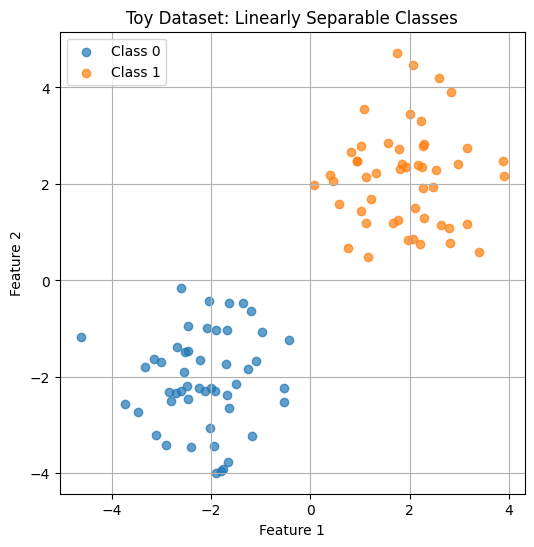

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Set seed for reproducibility
np.random.seed(42)

# Generate 2D points for class 0
class0 = np.random.randn(50, 2) + np.array([-2, -2])  # shifted bottom-left

# Generate 2D points for class 1
class1 = np.random.randn(50, 2) + np.array([2, 2])    # shifted top-right

# Stack into full dataset
X = np.vstack((class0, class1))
y = np.array([0]*50 + [1]*50)  # Labels

# Visualize
plt.figure(figsize=(6, 6))
plt.scatter(X[y==0][:, 0], X[y==0][:, 1], label='Class 0', alpha=0.7)
plt.scatter(X[y==1][:, 0], X[y==1][:, 1], label='Class 1', alpha=0.7)
plt.title("Toy Dataset: Linearly Separable Classes")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

In [7]:
X

array([[-1.50328585, -2.1382643 ],
       [-1.35231146, -0.47697014],
       [-2.23415337, -2.23413696],
       [-0.42078718, -1.23256527],
       [-2.46947439, -1.45743996],
       [-2.46341769, -2.46572975],
       [-1.75803773, -3.91328024],
       [-3.72491783, -2.56228753],
       [-3.01283112, -1.68575267],
       [-2.90802408, -3.4123037 ],
       [-0.53435123, -2.2257763 ],
       [-1.9324718 , -3.42474819],
       [-2.54438272, -1.88907741],
       [-3.15099358, -1.62430198],
       [-2.60063869, -2.29169375],
       [-2.60170661, -0.14772182],
       [-2.01349722, -3.05771093],
       [-1.17745509, -3.22084365],
       [-1.7911364 , -3.95967012],
       [-3.32818605, -1.80313876],
       [-1.26153342, -1.82863172],
       [-2.11564828, -2.3011037 ],
       [-3.47852199, -2.71984421],
       [-2.46063877, -0.94287777],
       [-1.65638171, -3.76304016],
       [-1.67591603, -2.38508228],
       [-2.676922  , -1.38832371],
       [-0.96900048, -1.06871988],
       [-2.83921752,

In [8]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [9]:
import numpy as np

# Load toy data from Section 2
# X: (100, 2), y: (100,)
# Assuming X and y are already available from earlier

# Initialize weights and bias
w = np.zeros(X.shape[1])  # shape (2,)
b = 4.0

# Learning rate and epochs
lr = 0.1
epochs = 5
errors_per_epoch = []

# Step function
def step(z):
    return 1 if z >= 0 else 0

# Training loop
for epoch in range(epochs):
    total_errors = 0
    for xi, yi in zip(X, y):
        z = np.dot(w, xi) + b
        y_hat = step(z)

        # Perceptron update rule
        error = yi - y_hat
        if error != 0:
            w += lr * error * xi
            b += lr * error
            total_errors += 1

    errors_per_epoch.append(total_errors)
    print(f"Epoch {epoch+1}: errors = {total_errors}")

Epoch 1: errors = 10
Epoch 2: errors = 2
Epoch 3: errors = 1
Epoch 4: errors = 0
Epoch 5: errors = 0


In [10]:
z

np.float64(7.5481574913056075)